# Notebook 05 — Final GMM C5 Spherical and Membership Evidence

## Purpose

Notebook 04 selected and froze **GMM C5 Spherical** as the final supporting probabilistic model. This notebook does **not retrain or re-select** the GMM. Instead, it loads the frozen model and examines customer-level membership evidence in detail.

For every one of the **4,338 customers**, the notebook calculates:

- assigned GMM component;
- maximum posterior membership probability;
- second-highest probability;
- alternative component;
- probability margin;
- normalised entropy;
- individual hard-assignment Silhouette value;
- descriptive strong, moderate and ambiguous membership categories.

The purpose is to quantify how decisively the fitted GMM supports each customer's assignment, while keeping the distinction between **probabilistic membership evidence** and **geometric cluster separation** clear.

> The confidence categories are dissertation-specific descriptive review rules. They are not classification accuracy, error rates or probabilities that a business label is objectively correct.


## Relationship with the K-Means confidence analysis

Notebook 03 measured K-Means confidence using individual Silhouette values, distances to the assigned and second-nearest centroids, and the relative centroid margin.

GMM provides a different form of evidence because it returns posterior probabilities for all five components. This notebook therefore measures membership concentration and ambiguity using probability-based quantities. The two confidence frameworks are compared directly later in Notebook 06.


## 1. Import libraries

In [10]:
import os
import json
import shutil
import zipfile
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    silhouette_score,
    silhouette_samples
)

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 400)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}"
)

sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Configure input archives, thresholds and output folders

This notebook can run directly from the final ZIP archives produced by Notebook 01 and Notebook 04. It automatically locates the processed customer data, original-scale customer data and frozen GMM C5 Spherical artefacts.


In [11]:
# ------------------------------------------------------------
# Runtime root
# ------------------------------------------------------------

CONTENT_DIR = Path("/content")
SANDBOX_DIR = Path("/mnt/data")

if (
    CONTENT_DIR
    / "04_GMM_Evaluation_and_Model_Selection_All_Results.zip"
).exists():
    BASE_DIR = CONTENT_DIR
elif (
    SANDBOX_DIR
    / "04_GMM_Evaluation_and_Model_Selection_All_Results.zip"
).exists():
    BASE_DIR = SANDBOX_DIR
else:
    # Google Colab uses /content, so keep that as the default
    # when the input ZIP has not yet been uploaded.
    BASE_DIR = CONTENT_DIR

# ------------------------------------------------------------
# Input ZIP archives
# ------------------------------------------------------------

NOTEBOOK01_ZIP = (
    BASE_DIR
    / "01_Data_Preparation_and_Feature_Engineering_All_Results.zip"
)

NOTEBOOK04_ZIP = (
    BASE_DIR
    / "04_GMM_Evaluation_and_Model_Selection_All_Results.zip"
)

NOTEBOOK01_EXTRACT_DIR = (
    BASE_DIR
    / "Notebook01_Extracted_For_Notebook05"
)

NOTEBOOK04_EXTRACT_DIR = (
    BASE_DIR
    / "Notebook04_Extracted_For_Notebook05"
)

# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

RESULTS_DIR = (
    BASE_DIR
    / "05_Final_GMM_C5_Spherical_and_Membership_Results"
)

TABLES_DIR = RESULTS_DIR / "Tables"
FIGURES_DIR = RESULTS_DIR / "Figures"
DATASETS_DIR = RESULTS_DIR / "Datasets"
QUALITY_DIR = RESULTS_DIR / "Quality_Checks"

for folder in [
    RESULTS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    DATASETS_DIR,
    QUALITY_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

FEATURE_COLUMNS = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageOrderValue",
    "BasketSize",
    "ProductDiversity",
    "TotalQuantity"
]

EXPECTED_CUSTOMERS = 4338
EXPECTED_COMPONENTS = 5
EXPECTED_COVARIANCE_TYPE = "spherical"

# ------------------------------------------------------------
# Main descriptive membership thresholds
# ------------------------------------------------------------

LOW_MAX_PROBABILITY_THRESHOLD = 0.60
LOW_PROBABILITY_MARGIN_THRESHOLD = 0.20
HIGH_ENTROPY_THRESHOLD = 0.50

# Strong-membership conditions.
STRONG_MAX_PROBABILITY_THRESHOLD = 0.80
STRONG_PROBABILITY_MARGIN_THRESHOLD = 0.40
STRONG_ENTROPY_THRESHOLD = 0.30

print("Runtime root:", BASE_DIR)
print("Notebook 01 ZIP:", NOTEBOOK01_ZIP)
print("Notebook 04 ZIP:", NOTEBOOK04_ZIP)
print("Output directory:", RESULTS_DIR)


Runtime root: /content
Notebook 01 ZIP: /content/01_Data_Preparation_and_Feature_Engineering_All_Results.zip
Notebook 04 ZIP: /content/04_GMM_Evaluation_and_Model_Selection_All_Results.zip
Output directory: /content/05_Final_GMM_C5_Spherical_and_Membership_Results


### Main descriptive membership conditions

A customer is placed in the **low-confidence / ambiguous review group** when **any** of these conditions is met:

- maximum probability < 0.60;
- probability margin < 0.20;
- normalised entropy > 0.50.

Strong membership requires all of the following:

- maximum probability ≥ 0.80;
- probability margin ≥ 0.40;
- normalised entropy ≤ 0.30.

Customers who are neither ambiguous nor strong are labelled **moderate membership**.


## 3. Extract Notebook 01 and Notebook 04 outputs

The code below locates the two customer feature files from Notebook 01 and the frozen selected GMM model, customer assignments and selection evidence from Notebook 04.


In [12]:
def extract_clean(zip_path, destination):
    if not zip_path.exists():
        raise FileNotFoundError(
            f"Required ZIP not found: {zip_path}"
        )

    if destination.exists():
        shutil.rmtree(destination)

    destination.mkdir(
        parents=True,
        exist_ok=True
    )

    with zipfile.ZipFile(zip_path) as archive:
        archive.extractall(destination)


def find_required_file(root, filename):
    matches = list(
        Path(root).rglob(filename)
    )

    if not matches:
        raise FileNotFoundError(
            f"Could not locate {filename} under {root}"
        )

    if len(matches) > 1:
        print(
            f"Multiple matches found for {filename}; "
            f"using: {matches[0]}"
        )

    return matches[0]


extract_clean(
    NOTEBOOK01_ZIP,
    NOTEBOOK01_EXTRACT_DIR
)

extract_clean(
    NOTEBOOK04_ZIP,
    NOTEBOOK04_EXTRACT_DIR
)

PROCESSED_FILE = find_required_file(
    NOTEBOOK01_EXTRACT_DIR,
    "customer_features_processed.csv"
)

ORIGINAL_SCALE_FILE = find_required_file(
    NOTEBOOK01_EXTRACT_DIR,
    "customer_features_ready_for_preprocessing.csv"
)

FROZEN_MODEL_FILE = find_required_file(
    NOTEBOOK04_EXTRACT_DIR,
    "final_gmm_c5_model.joblib"
)

FROZEN_CUSTOMER_DATA_FILE = find_required_file(
    NOTEBOOK04_EXTRACT_DIR,
    "final_gmm_c5_customer_data.csv"
)

FROZEN_SELECTION_RECORD = find_required_file(
    NOTEBOOK04_EXTRACT_DIR,
    "final_gmm_c5_freeze_record.json"
)

FROZEN_SELECTION_EVIDENCE = find_required_file(
    NOTEBOOK04_EXTRACT_DIR,
    "final_gmm_c5_selected_evidence.csv"
)

print("=" * 80)
print("NOTEBOOK 05 INPUTS LOCATED")
print("=" * 80)

print("Processed data:")
print(PROCESSED_FILE)

print("\nOriginal-scale data:")
print(ORIGINAL_SCALE_FILE)

print("\nFrozen GMM model:")
print(FROZEN_MODEL_FILE)

print("\nFrozen customer assignments:")
print(FROZEN_CUSTOMER_DATA_FILE)

print("\nFreeze record:")
print(FROZEN_SELECTION_RECORD)

print("\nSelected evidence:")
print(FROZEN_SELECTION_EVIDENCE)


NOTEBOOK 05 INPUTS LOCATED
Processed data:
/content/Notebook01_Extracted_For_Notebook05/Advanced_Preprocessing_Results/Data/customer_features_processed.csv

Original-scale data:
/content/Notebook01_Extracted_For_Notebook05/Results/Data/customer_features_ready_for_preprocessing.csv

Frozen GMM model:
/content/Notebook04_Extracted_For_Notebook05/02_Final_C5_Selection/Models/final_gmm_c5_model.joblib

Frozen customer assignments:
/content/Notebook04_Extracted_For_Notebook05/02_Final_C5_Selection/Assignments/final_gmm_c5_customer_data.csv

Freeze record:
/content/Notebook04_Extracted_For_Notebook05/02_Final_C5_Selection/Selection/final_gmm_c5_freeze_record.json

Selected evidence:
/content/Notebook04_Extracted_For_Notebook05/02_Final_C5_Selection/Selection/final_gmm_c5_selected_evidence.csv


## 4. Load and validate the frozen GMM analytical inputs


In [13]:
processed_data = pd.read_csv(
    PROCESSED_FILE
)

original_scale_data = pd.read_csv(
    ORIGINAL_SCALE_FILE
)

frozen_customer_data = pd.read_csv(
    FROZEN_CUSTOMER_DATA_FILE
)

selected_evidence = pd.read_csv(
    FROZEN_SELECTION_EVIDENCE
)

with open(
    FROZEN_SELECTION_RECORD,
    "r"
) as file:
    freeze_record = json.load(file)

final_gmm = joblib.load(
    FROZEN_MODEL_FILE
)

REQUIRED_COLUMNS = [
    "CustomerID"
] + FEATURE_COLUMNS

for dataset_name, dataset in {
    "processed": processed_data,
    "original_scale": original_scale_data
}.items():

    missing_columns = [
        column
        for column in REQUIRED_COLUMNS
        if column not in dataset.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{dataset_name} data is missing: "
            f"{missing_columns}"
        )

    if dataset["CustomerID"].duplicated().any():
        raise ValueError(
            f"Duplicate CustomerID values found in "
            f"{dataset_name} data."
        )

original_scale_data = (
    processed_data[["CustomerID"]]
    .merge(
        original_scale_data[
            REQUIRED_COLUMNS
        ],
        on="CustomerID",
        how="left",
        validate="one_to_one"
    )
)

frozen_required_columns = [
    "CustomerID",
    "GMM_Component"
]

missing_frozen_columns = [
    column
    for column in frozen_required_columns
    if column not in frozen_customer_data.columns
]

if missing_frozen_columns:
    raise ValueError(
        "Frozen customer data is missing: "
        f"{missing_frozen_columns}"
    )

frozen_customer_data = (
    processed_data[["CustomerID"]]
    .merge(
        frozen_customer_data,
        on="CustomerID",
        how="left",
        validate="one_to_one"
    )
)

X = processed_data[
    FEATURE_COLUMNS
].copy()

if len(X) != EXPECTED_CUSTOMERS:
    raise ValueError(
        f"Expected {EXPECTED_CUSTOMERS:,} customers, "
        f"but found {len(X):,}."
    )

if X.shape[1] != 7:
    raise ValueError(
        "Expected exactly seven processed features."
    )

if X.isnull().sum().sum() > 0:
    raise ValueError(
        "Missing values found in the processed matrix."
    )

if not np.isfinite(
    X.to_numpy()
).all():
    raise ValueError(
        "Non-finite values found in the processed matrix."
    )

if final_gmm.n_components != EXPECTED_COMPONENTS:
    raise ValueError(
        "The loaded model is not a five-component GMM."
    )

if (
    final_gmm.covariance_type
    != EXPECTED_COVARIANCE_TYPE
):
    raise ValueError(
        "The loaded final model is not the selected "
        "spherical GMM."
    )

print("=" * 80)
print("FROZEN MODEL VALIDATION")
print("=" * 80)

print(
    "Selected configuration:",
    freeze_record.get(
        "selected_configuration"
    )
)

print(
    "Model components:",
    final_gmm.n_components
)

print(
    "Covariance type:",
    final_gmm.covariance_type
)

print(
    "Customers:",
    len(X)
)

display(selected_evidence)

FROZEN MODEL VALIDATION
Selected configuration: GMM_C5_spherical
Model components: 5
Covariance type: spherical
Customers: 4338


,Configuration,N_Components,Covariance_Type,Converged,Iterations,Fit_Time_Seconds,Average_Log_Likelihood,Lower_Bound,AIC,BIC,Silhouette_Score,Negative_Silhouette_Count,Negative_Silhouette_Percentage,Davies_Bouldin_Index,Calinski_Harabasz_Index,Smallest_Component_Count,Smallest_Component_Percentage,Largest_Component_Percentage,All_Components_At_Least_5_Percent,Minimum_Covariance_Value,Mean_Maximum_Probability,Median_Maximum_Probability,Low_Maximum_Probability_Count,Low_Maximum_Probability_Percentage,Mean_Probability_Margin,Median_Probability_Margin,Low_Probability_Margin_Count,Low_Probability_Margin_Percentage,Mean_Normalised_Entropy,Median_Normalised_Entropy,Requested_Runs_Seed,Successful_Runs_Seed,Convergence_Rate_Seed,Mean_Seed_ARI,Median_Seed_ARI,Minimum_Seed_ARI,Maximum_Seed_ARI,Seed_ARI_Standard_Deviation,Mean_AIC_Across_Seeds,Mean_BIC_Across_Seeds,Requested_Runs_Subsample,Successful_Runs_Subsample,Sample_Size,Sample_Fraction,Convergence_Rate_Subsample,Mean_Subsampling_ARI,Median_Subsampling_ARI,Minimum_Subsampling_ARI,Maximum_Subsampling_ARI,Subsampling_ARI_Standard_Deviation,Mean_Smallest_Sample_Component_Percentage,Minimum_Smallest_Sample_Component_Percentage,Passes_Component_Feasibility,Passes_Seed_Stability,Passes_Subsampling_Stability,Passes_Operational_Gates
0,GMM_C5_spherical,5,spherical,True,11,0.9737,-5.8326,-5.8329,"50,691.2165","50,971.7240",0.2299,628,14.4767,1.3749,"1,587.4952",494,11.3877,37.0678,True,0.1421,0.9221,0.9908,227,5.2328,0.8503,0.9827,194,4.4721,0.1201,0.0338,30,30,1.0000,0.9985,0.9992,0.9918,1.0000,0.0020,"50,691.2220","50,971.7294",50,50,3470,0.8000,1.0000,0.9610,0.9660,0.8898,0.9879,0.0202,11.4259,10.7781,True,True,True,True


## 5. Reproduce the frozen assignments and posterior probabilities

The model is loaded and applied to the same processed feature matrix.

The reproduced assignments must exactly match the assignments saved by the
final-model notebook.

In [14]:
reproduced_labels = final_gmm.predict(
    X
)

reproduced_probabilities = (
    final_gmm.predict_proba(
        X
    )
)

frozen_labels = (
    frozen_customer_data[
        "GMM_Component"
    ]
    .astype(int)
    .to_numpy()
)

if not np.array_equal(
    reproduced_labels,
    frozen_labels
):
    raise AssertionError(
        "The loaded GMM did not reproduce the "
        "frozen component assignments."
    )

if not np.allclose(
    reproduced_probabilities.sum(axis=1),
    1.0
):
    raise AssertionError(
        "Posterior probabilities do not sum to one."
    )

if np.any(
    reproduced_probabilities < 0
):
    raise AssertionError(
        "Negative posterior probabilities found."
    )

print(
    "Frozen assignments reproduced exactly:",
    True
)

print(
    "Probability rows sum to one:",
    True
)

Frozen assignments reproduced exactly: True
Probability rows sum to one: True


## 6. Calculate customer-level GMM membership evidence

For each customer, the notebook identifies:

- assigned component;
- alternative component;
- maximum posterior probability;
- second-highest posterior probability;
- probability margin;
- probability ratio;
- normalised entropy;
- individual Silhouette Value.

### Probability margin

\[
P_{\text{maximum}} - P_{\text{second}}
\]

A larger value indicates a clearer preference for the assigned component.

### Normalised entropy

A lower value means the probability is concentrated in one component. A
higher value means membership is distributed across several components.

In [15]:
sorted_component_indices = np.argsort(
    reproduced_probabilities,
    axis=1
)

assigned_component = (
    sorted_component_indices[:, -1]
)

alternative_component = (
    sorted_component_indices[:, -2]
)

row_indices = np.arange(
    len(X)
)

maximum_probability = (
    reproduced_probabilities[
        row_indices,
        assigned_component
    ]
)

second_probability = (
    reproduced_probabilities[
        row_indices,
        alternative_component
    ]
)

probability_margin = (
    maximum_probability
    - second_probability
)

safe_maximum_probability = np.maximum(
    maximum_probability,
    np.finfo(float).eps
)

alternative_to_assigned_ratio = (
    second_probability
    / safe_maximum_probability
)

clipped_probabilities = np.clip(
    reproduced_probabilities,
    1e-15,
    1.0
)

membership_entropy = -np.sum(
    clipped_probabilities
    * np.log(
        clipped_probabilities
    ),
    axis=1
)

normalised_entropy = (
    membership_entropy
    / np.log(
        EXPECTED_COMPONENTS
    )
)

individual_silhouette = (
    silhouette_samples(
        X,
        reproduced_labels
    )
)

overall_silhouette = silhouette_score(
    X,
    reproduced_labels
)

if not np.array_equal(
    assigned_component,
    reproduced_labels
):
    raise AssertionError(
        "Maximum-probability components do not match "
        "the GMM hard assignments."
    )

membership_data = (
    original_scale_data.copy()
)

membership_data[
    "GMM_Component"
] = assigned_component

membership_data[
    "Alternative_GMM_Component"
] = alternative_component

membership_data[
    "Maximum_Probability"
] = maximum_probability

membership_data[
    "Second_Probability"
] = second_probability

membership_data[
    "Probability_Margin"
] = probability_margin

membership_data[
    "Alternative_to_Assigned_Probability_Ratio"
] = alternative_to_assigned_ratio

membership_data[
    "Normalised_Entropy"
] = normalised_entropy

membership_data[
    "Silhouette_Value"
] = individual_silhouette

for component_index in range(
    EXPECTED_COMPONENTS
):
    membership_data[
        f"Component_{component_index}_Probability"
    ] = reproduced_probabilities[
        :,
        component_index
    ]

print(
    "Overall Silhouette Score:",
    round(
        overall_silhouette,
        4
    )
)

display(
    membership_data.head()
)

Overall Silhouette Score: 0.2299


,CustomerID,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity,GMM_Component,Alternative_GMM_Component,Maximum_Probability,Second_Probability,Probability_Margin,Alternative_to_Assigned_Probability_Ratio,Normalised_Entropy,Silhouette_Value,Component_0_Probability,Component_1_Probability,Component_2_Probability,Component_3_Probability,Component_4_Probability
0,12346,326,1,"77,183.6000","77,183.6000","74,215.0000",1,74215,1,4,1.0000,0.0000,1.0000,0.0000,0.0000,0.1461,0.0000,1.0000,0.0000,0.0000,0.0000
1,12347,2,7,"4,310.0000",615.7100,351.1400,103,2458,2,1,0.9751,0.0249,0.9502,0.0255,0.0724,0.4080,0.0000,0.0249,0.9751,0.0000,0.0000
2,12348,75,4,"1,797.2400",449.3100,585.2500,22,2341,1,2,0.8729,0.1229,0.7500,0.1408,0.2480,-0.1604,0.0041,0.8729,0.1229,0.0000,0.0000
3,12349,19,1,"1,757.5500","1,757.5500",631.0000,73,631,1,2,1.0000,0.0000,1.0000,0.0000,0.0000,0.1515,0.0000,1.0000,0.0000,0.0000,0.0000
4,12350,310,1,334.4000,334.4000,197.0000,17,197,3,4,1.0000,0.0000,0.9999,0.0000,0.0003,0.5486,0.0000,0.0000,0.0000,1.0000,0.0000


## 7. Create strong, moderate and ambiguous membership categories


In [16]:
low_max_probability_flag = (
    maximum_probability
    < LOW_MAX_PROBABILITY_THRESHOLD
)

low_probability_margin_flag = (
    probability_margin
    < LOW_PROBABILITY_MARGIN_THRESHOLD
)

high_entropy_flag = (
    normalised_entropy
    > HIGH_ENTROPY_THRESHOLD
)

combined_ambiguous_flag = (
    low_max_probability_flag
    | low_probability_margin_flag
    | high_entropy_flag
)

strong_membership_flag = (
    (
        maximum_probability
        >= STRONG_MAX_PROBABILITY_THRESHOLD
    )
    &
    (
        probability_margin
        >= STRONG_PROBABILITY_MARGIN_THRESHOLD
    )
    &
    (
        normalised_entropy
        <= STRONG_ENTROPY_THRESHOLD
    )
)

membership_confidence_category = np.select(
    [
        combined_ambiguous_flag,
        strong_membership_flag
    ],
    [
        "Low-Confidence / Ambiguous Membership",
        "Strong Membership"
    ],
    default="Moderate Membership"
)

membership_data[
    "Low_Maximum_Probability_Flag"
] = low_max_probability_flag

membership_data[
    "Low_Probability_Margin_Flag"
] = low_probability_margin_flag

membership_data[
    "High_Entropy_Flag"
] = high_entropy_flag

membership_data[
    "Combined_Ambiguous_Flag"
] = combined_ambiguous_flag

membership_data[
    "Membership_Confidence_Category"
] = membership_confidence_category

print(
    "Membership-confidence categories added."
)

Membership-confidence categories added.


## 8. Summarise overall GMM membership evidence


In [17]:
condition_summary = pd.DataFrame({
    "Condition": [
        (
            "Maximum probability "
            f"< {LOW_MAX_PROBABILITY_THRESHOLD:.2f}"
        ),
        (
            "Probability margin "
            f"< {LOW_PROBABILITY_MARGIN_THRESHOLD:.2f}"
        ),
        (
            "Normalised entropy "
            f"> {HIGH_ENTROPY_THRESHOLD:.2f}"
        ),
        "Combined low-confidence / ambiguous group",
        "Negative Silhouette"
    ],
    "Customer_Count": [
        int(
            low_max_probability_flag.sum()
        ),
        int(
            low_probability_margin_flag.sum()
        ),
        int(
            high_entropy_flag.sum()
        ),
        int(
            combined_ambiguous_flag.sum()
        ),
        int(
            (
                individual_silhouette < 0
            ).sum()
        )
    ]
})

condition_summary[
    "Customer_Percentage"
] = (
    condition_summary[
        "Customer_Count"
    ]
    / len(membership_data)
    * 100
)

confidence_category_summary = (
    membership_data[
        "Membership_Confidence_Category"
    ]
    .value_counts()
    .reindex(
        [
            "Strong Membership",
            "Moderate Membership",
            "Low-Confidence / Ambiguous Membership"
        ],
        fill_value=0
    )
    .rename_axis(
        "Membership_Confidence_Category"
    )
    .reset_index(
        name="Customer_Count"
    )
)

confidence_category_summary[
    "Customer_Percentage"
] = (
    confidence_category_summary[
        "Customer_Count"
    ]
    / len(membership_data)
    * 100
)

probability_descriptive_summary = (
    membership_data[
        [
            "Maximum_Probability",
            "Second_Probability",
            "Probability_Margin",
            "Alternative_to_Assigned_Probability_Ratio",
            "Normalised_Entropy",
            "Silhouette_Value"
        ]
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .T
)

print("=" * 80)
print("OVERALL GMM MEMBERSHIP CONFIDENCE")
print("=" * 80)

display(
    condition_summary.round(4)
)

display(
    confidence_category_summary.round(4)
)

display(
    probability_descriptive_summary.round(4)
)

OVERALL GMM MEMBERSHIP CONFIDENCE


,Condition,Customer_Count,Customer_Percentage
0,Maximum probability < 0.60,227,5.2328
1,Probability margin < 0.20,194,4.4721
2,Normalised entropy > 0.50,103,2.3744
3,Combined low-confidence / ambiguous group,259,5.9705
4,Negative Silhouette,628,14.4767


,Membership_Confidence_Category,Customer_Count,Customer_Percentage
0,Strong Membership,3584,82.6187
1,Moderate Membership,495,11.4108
2,Low-Confidence / Ambiguous Membership,259,5.9705


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
Maximum_Probability,"4,338.0000",0.9221,0.1304,0.3626,0.5035,0.5974,0.6995,0.9089,0.9908,0.9991,0.9999,1.0000,1.0000,1.0000
Second_Probability,"4,338.0000",0.0718,0.1203,0.0000,0.0000,0.0000,0.0000,0.0007,0.0080,0.0826,0.2787,0.3675,0.4666,0.4987
Probability_Margin,"4,338.0000",0.8503,0.2497,0.0002,0.0405,0.2225,0.4171,0.8255,0.9827,0.9984,0.9999,1.0000,1.0000,1.0000
Alternative_to_Assigned_Probability_Ratio,"4,338.0000",0.1063,0.2059,0.0000,0.0000,0.0000,0.0000,0.0007,0.0081,0.0908,0.4005,0.6234,0.9197,0.9995
Normalised_Entropy,"4,338.0000",0.1201,0.1585,0.0000,0.0000,0.0000,0.0004,0.0046,0.0338,0.1969,0.3960,0.4358,0.5940,0.7705
Silhouette_Value,"4,338.0000",0.2299,0.1958,-0.4282,-0.2682,-0.1414,-0.0589,0.1071,0.2585,0.3796,0.4643,0.5029,0.5483,0.5728


## 9. Summarise membership evidence within each component

The component summary identifies where probabilistic uncertainty and geometric
overlap are concentrated.

In [18]:
component_confidence_summary = (
    membership_data
    .groupby(
        "GMM_Component"
    )
    .agg(
        Customer_Count=(
            "CustomerID",
            "count"
        ),
        Mean_Maximum_Probability=(
            "Maximum_Probability",
            "mean"
        ),
        Median_Maximum_Probability=(
            "Maximum_Probability",
            "median"
        ),
        Mean_Probability_Margin=(
            "Probability_Margin",
            "mean"
        ),
        Median_Probability_Margin=(
            "Probability_Margin",
            "median"
        ),
        Mean_Normalised_Entropy=(
            "Normalised_Entropy",
            "mean"
        ),
        Median_Normalised_Entropy=(
            "Normalised_Entropy",
            "median"
        ),
        Mean_Silhouette=(
            "Silhouette_Value",
            "mean"
        ),
        Median_Silhouette=(
            "Silhouette_Value",
            "median"
        ),
        Low_Maximum_Probability_Customers=(
            "Low_Maximum_Probability_Flag",
            "sum"
        ),
        Low_Probability_Margin_Customers=(
            "Low_Probability_Margin_Flag",
            "sum"
        ),
        High_Entropy_Customers=(
            "High_Entropy_Flag",
            "sum"
        ),
        Ambiguous_Customers=(
            "Combined_Ambiguous_Flag",
            "sum"
        )
    )
    .reset_index()
)

for count_column, percentage_column in [
    (
        "Low_Maximum_Probability_Customers",
        "Low_Maximum_Probability_Percentage"
    ),
    (
        "Low_Probability_Margin_Customers",
        "Low_Probability_Margin_Percentage"
    ),
    (
        "High_Entropy_Customers",
        "High_Entropy_Percentage"
    ),
    (
        "Ambiguous_Customers",
        "Ambiguous_Percentage"
    )
]:
    component_confidence_summary[
        percentage_column
    ] = (
        component_confidence_summary[
            count_column
        ]
        / component_confidence_summary[
            "Customer_Count"
        ]
        * 100
    )

component_category_counts = (
    membership_data
    .groupby(
        [
            "GMM_Component",
            "Membership_Confidence_Category"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reset_index()
)

component_confidence_summary = (
    component_confidence_summary
    .merge(
        component_category_counts,
        on="GMM_Component",
        how="left",
        validate="one_to_one"
    )
    .round(4)
)

display(component_confidence_summary)

,GMM_Component,Customer_Count,Mean_Maximum_Probability,Median_Maximum_Probability,Mean_Probability_Margin,Median_Probability_Margin,Mean_Normalised_Entropy,Median_Normalised_Entropy,Mean_Silhouette,Median_Silhouette,Low_Maximum_Probability_Customers,Low_Probability_Margin_Customers,High_Entropy_Customers,Ambiguous_Customers,Low_Maximum_Probability_Percentage,Low_Probability_Margin_Percentage,High_Entropy_Percentage,Ambiguous_Percentage,Low-Confidence / Ambiguous Membership,Moderate Membership,Strong Membership
0,0,1608,0.9212,0.9882,0.8494,0.9776,0.1244,0.0417,0.2358,0.2528,80,65,40,94,4.9751,4.0423,2.4876,5.8458,94,184,1330
1,1,494,0.9219,0.9951,0.8495,0.9901,0.1155,0.0194,-0.0523,-0.0762,30,23,15,34,6.0729,4.6559,3.0364,6.8826,34,52,408
2,2,1017,0.9189,0.9855,0.8428,0.9721,0.1261,0.0482,0.3630,0.3802,54,50,15,59,5.3097,4.9164,1.4749,5.8014,59,124,834
3,3,528,0.9137,0.9910,0.8356,0.9826,0.1316,0.0332,0.3656,0.3836,32,28,20,37,6.0606,5.3030,3.7879,7.0076,37,70,421
4,4,691,0.9355,0.9988,0.8756,0.9976,0.0958,0.0061,0.1183,0.1363,31,28,13,35,4.4863,4.0521,1.8813,5.0651,35,65,591


## 10. Analyse assigned versus alternative GMM components

The alternative component is the component with the second-highest posterior
probability.

This identifies which component pairs compete most strongly for the same
customers.

In [19]:
ambiguous_customers = (
    membership_data[
        membership_data[
            "Combined_Ambiguous_Flag"
        ]
    ]
    .copy()
    .sort_values(
        [
            "Probability_Margin",
            "Maximum_Probability",
            "Normalised_Entropy"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

assigned_alternative_matrix = pd.crosstab(
    membership_data[
        "GMM_Component"
    ],
    membership_data[
        "Alternative_GMM_Component"
    ],
    margins=True,
    margins_name="Total"
)

ambiguous_overlap_matrix = pd.crosstab(
    ambiguous_customers[
        "GMM_Component"
    ],
    ambiguous_customers[
        "Alternative_GMM_Component"
    ],
    margins=True,
    margins_name="Total"
)

component_overlap_summary = (
    ambiguous_customers
    .groupby(
        [
            "GMM_Component",
            "Alternative_GMM_Component"
        ]
    )
    .agg(
        Ambiguous_Customer_Count=(
            "CustomerID",
            "count"
        ),
        Mean_Maximum_Probability=(
            "Maximum_Probability",
            "mean"
        ),
        Mean_Second_Probability=(
            "Second_Probability",
            "mean"
        ),
        Mean_Probability_Margin=(
            "Probability_Margin",
            "mean"
        ),
        Mean_Normalised_Entropy=(
            "Normalised_Entropy",
            "mean"
        ),
        Mean_Silhouette=(
            "Silhouette_Value",
            "mean"
        )
    )
    .reset_index()
)

assigned_ambiguous_totals = (
    ambiguous_customers
    .groupby(
        "GMM_Component"
    )
    .size()
    .reset_index(
        name="Assigned_Component_Ambiguous_Total"
    )
)

component_overlap_summary = (
    component_overlap_summary
    .merge(
        assigned_ambiguous_totals,
        on="GMM_Component",
        how="left",
        validate="many_to_one"
    )
)

component_overlap_summary[
    "Percentage_of_Assigned_Component_Ambiguous_Customers"
] = (
    component_overlap_summary[
        "Ambiguous_Customer_Count"
    ]
    / component_overlap_summary[
        "Assigned_Component_Ambiguous_Total"
    ]
    * 100
)

component_overlap_summary = (
    component_overlap_summary
    .sort_values(
        [
            "Ambiguous_Customer_Count",
            "GMM_Component"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
    .round(4)
)

display(
    component_overlap_summary.head(20)
)

print("\nAll customers:")
display(assigned_alternative_matrix)

print("\nLow-confidence customers only:")
display(ambiguous_overlap_matrix)

,GMM_Component,Alternative_GMM_Component,Ambiguous_Customer_Count,Mean_Maximum_Probability,Mean_Second_Probability,Mean_Probability_Margin,Mean_Normalised_Entropy,Mean_Silhouette,Assigned_Component_Ambiguous_Total,Percentage_of_Assigned_Component_Ambiguous_Customers
0,2,0,34,0.5635,0.4010,0.1625,0.4725,0.1022,59,57.6271
1,0,2,31,0.5533,0.3923,0.1610,0.5028,-0.0612,94,32.9787
2,0,4,25,0.5527,0.3884,0.1643,0.4912,0.0797,94,26.5957
3,2,1,25,0.5341,0.4230,0.1112,0.4819,0.2407,59,42.3729
4,1,2,21,0.5550,0.4009,0.1541,0.4767,-0.2674,34,61.7647
5,0,3,20,0.5481,0.3909,0.1571,0.5056,-0.0729,94,21.2766
6,4,0,20,0.5339,0.4032,0.1307,0.5007,-0.1301,35,57.1429
7,0,1,18,0.5398,0.3677,0.1721,0.5405,0.0701,94,19.1489
8,3,4,18,0.5579,0.3790,0.1788,0.5049,0.1803,37,48.6486
9,4,3,14,0.5530,0.3978,0.1552,0.4860,-0.1721,35,40.0000



All customers:


Alternative_GMM_Component,0,1,2,3,4,Total
GMM_Component,,,,,,
0,0,330,509,162,607,1608
1,139,0,288,46,21,494
2,360,657,0,0,0,1017
3,147,77,0,0,304,528
4,324,93,0,274,0,691
Total,970,1157,797,482,932,4338



Low-confidence customers only:


Alternative_GMM_Component,0,1,2,3,4,Total
GMM_Component,,,,,,
0,0,18,31,20,25,94
1,11,0,21,2,0,34
2,34,25,0,0,0,59
3,13,6,0,0,18,37
4,20,1,0,14,0,35
Total,78,50,52,36,43,259


## 11. Compare probability evidence with individual Silhouette evidence

A GMM customer can have:

- high posterior membership but a negative Silhouette Value; or
- moderate probability uncertainty but a positive Silhouette Value.

This is possible because posterior probability and Silhouette measure
different aspects of membership.

In [20]:
negative_silhouette_flag = (
    membership_data[
        "Silhouette_Value"
    ] < 0
)

probability_silhouette_cross_summary = pd.DataFrame({
    "Condition": [
        "Negative Silhouette only",
        "GMM ambiguous only",
        "Both negative Silhouette and GMM ambiguous",
        "Neither condition"
    ],
    "Customer_Count": [
        int(
            (
                negative_silhouette_flag
                & ~combined_ambiguous_flag
            ).sum()
        ),
        int(
            (
                ~negative_silhouette_flag
                & combined_ambiguous_flag
            ).sum()
        ),
        int(
            (
                negative_silhouette_flag
                & combined_ambiguous_flag
            ).sum()
        ),
        int(
            (
                ~negative_silhouette_flag
                & ~combined_ambiguous_flag
            ).sum()
        )
    ]
})

probability_silhouette_cross_summary[
    "Customer_Percentage"
] = (
    probability_silhouette_cross_summary[
        "Customer_Count"
    ]
    / len(membership_data)
    * 100
)

confidence_silhouette_matrix = pd.crosstab(
    membership_data[
        "Membership_Confidence_Category"
    ],
    pd.cut(
        membership_data[
            "Silhouette_Value"
        ],
        bins=[
            -np.inf,
            0,
            0.25,
            np.inf
        ],
        labels=[
            "Negative Silhouette",
            "Silhouette 0 to <0.25",
            "Silhouette >=0.25"
        ],
        right=False
    ),
    margins=True,
    margins_name="Total"
)

display(
    probability_silhouette_cross_summary.round(4)
)

display(
    confidence_silhouette_matrix
)

,Condition,Customer_Count,Customer_Percentage
0,Negative Silhouette only,499,11.5030
1,GMM ambiguous only,130,2.9968
2,Both negative Silhouette and GMM ambiguous,129,2.9737
3,Neither condition,3580,82.5265


Silhouette_Value,Negative Silhouette,Silhouette 0 to <0.25,Silhouette >=0.25,Total
Membership_Confidence_Category,,,,
Low-Confidence / Ambiguous Membership,129,116,14,259
Moderate Membership,186,249,60,495
Strong Membership,313,1098,2173,3584
Total,628,1463,2247,4338


## 12. Test sensitivity to the membership thresholds

The notebook varies each threshold separately while holding the other two main
conditions constant.

This shows whether the reported low-confidence rate changes substantially
under reasonable alternative review thresholds.

In [21]:
maximum_probability_thresholds = [
    0.50,
    0.55,
    0.60,
    0.65,
    0.70
]

probability_margin_thresholds = [
    0.10,
    0.15,
    0.20,
    0.25,
    0.30
]

entropy_thresholds = [
    0.30,
    0.40,
    0.50,
    0.60,
    0.70
]

maximum_probability_sensitivity = []

for threshold in maximum_probability_thresholds:

    combined_flag = (
        (
            maximum_probability
            < threshold
        )
        |
        (
            probability_margin
            < LOW_PROBABILITY_MARGIN_THRESHOLD
        )
        |
        (
            normalised_entropy
            > HIGH_ENTROPY_THRESHOLD
        )
    )

    maximum_probability_sensitivity.append({
        "Maximum_Probability_Threshold": threshold,
        "Ambiguous_Customer_Count": int(
            combined_flag.sum()
        ),
        "Ambiguous_Customer_Percentage": float(
            combined_flag.mean()
            * 100
        )
    })

maximum_probability_sensitivity = pd.DataFrame(
    maximum_probability_sensitivity
)

probability_margin_sensitivity = []

for threshold in probability_margin_thresholds:

    combined_flag = (
        (
            maximum_probability
            < LOW_MAX_PROBABILITY_THRESHOLD
        )
        |
        (
            probability_margin
            < threshold
        )
        |
        (
            normalised_entropy
            > HIGH_ENTROPY_THRESHOLD
        )
    )

    probability_margin_sensitivity.append({
        "Probability_Margin_Threshold": threshold,
        "Ambiguous_Customer_Count": int(
            combined_flag.sum()
        ),
        "Ambiguous_Customer_Percentage": float(
            combined_flag.mean()
            * 100
        )
    })

probability_margin_sensitivity = pd.DataFrame(
    probability_margin_sensitivity
)

entropy_sensitivity = []

for threshold in entropy_thresholds:

    combined_flag = (
        (
            maximum_probability
            < LOW_MAX_PROBABILITY_THRESHOLD
        )
        |
        (
            probability_margin
            < LOW_PROBABILITY_MARGIN_THRESHOLD
        )
        |
        (
            normalised_entropy
            > threshold
        )
    )

    entropy_sensitivity.append({
        "Entropy_Threshold": threshold,
        "Ambiguous_Customer_Count": int(
            combined_flag.sum()
        ),
        "Ambiguous_Customer_Percentage": float(
            combined_flag.mean()
            * 100
        )
    })

entropy_sensitivity = pd.DataFrame(
    entropy_sensitivity
)

print("Maximum probability threshold sensitivity:")
display(maximum_probability_sensitivity)

print("\nProbability margin threshold sensitivity:")
display(probability_margin_sensitivity)

print("\nEntropy threshold sensitivity:")
display(entropy_sensitivity)

Maximum probability threshold sensitivity:


,Maximum_Probability_Threshold,Ambiguous_Customer_Count,Ambiguous_Customer_Percentage
0,0.5000,253,5.8322
1,0.5500,253,5.8322
2,0.6000,259,5.9705
3,0.6500,335,7.7225
4,0.7000,436,10.0507



Probability margin threshold sensitivity:


,Probability_Margin_Threshold,Ambiguous_Customer_Count,Ambiguous_Customer_Percentage
0,0.1000,259,5.9705
1,0.1500,259,5.9705
2,0.2000,259,5.9705
3,0.2500,289,6.6621
4,0.3000,332,7.6533



Entropy threshold sensitivity:


,Entropy_Threshold,Ambiguous_Customer_Count,Ambiguous_Customer_Percentage
0,0.3000,754,17.3813
1,0.4000,423,9.7510
2,0.5000,259,5.9705
3,0.6000,228,5.2559
4,0.7000,227,5.2328


## 13. Visualise customer-level GMM membership evidence


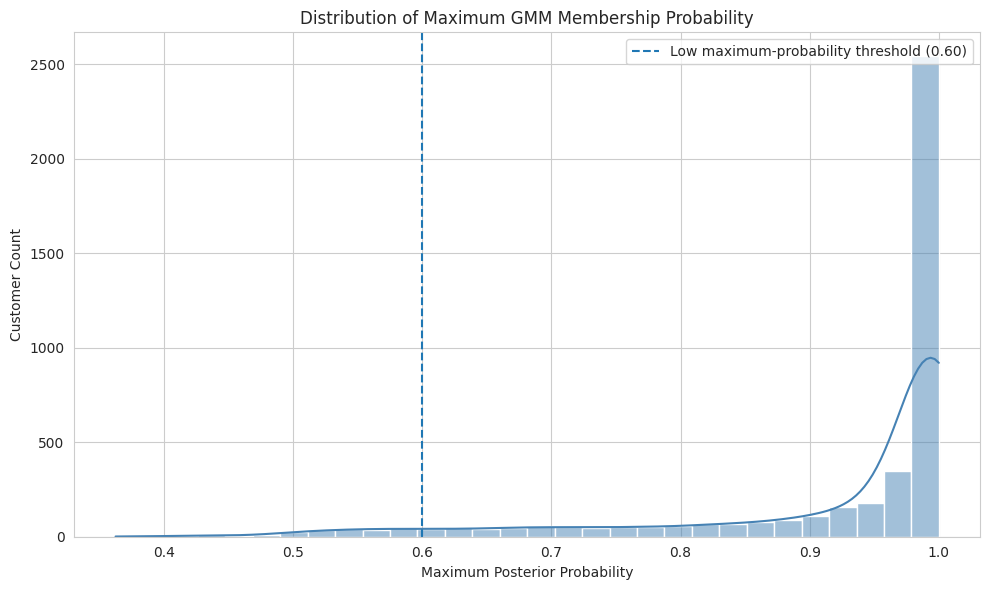

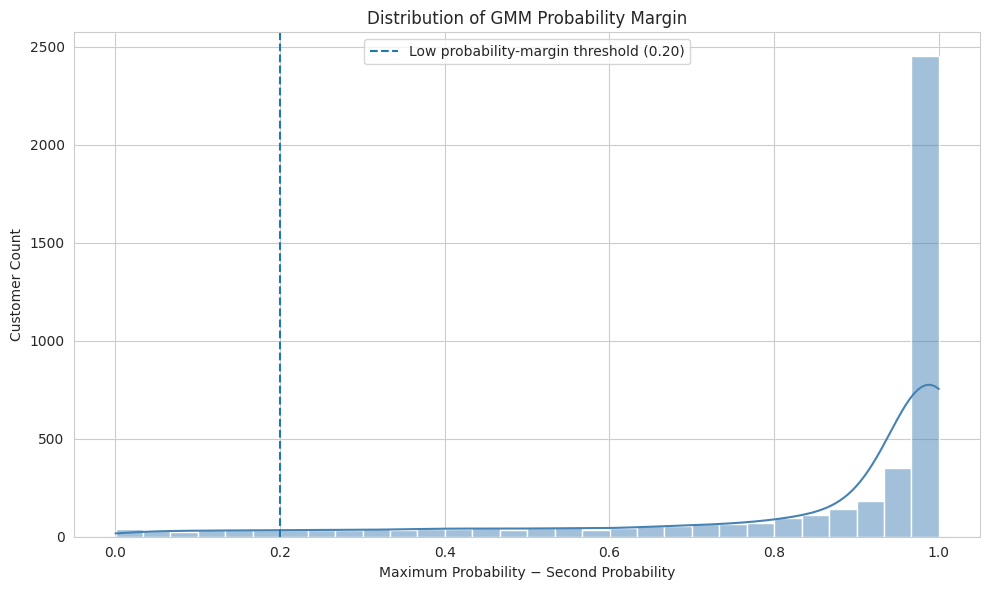

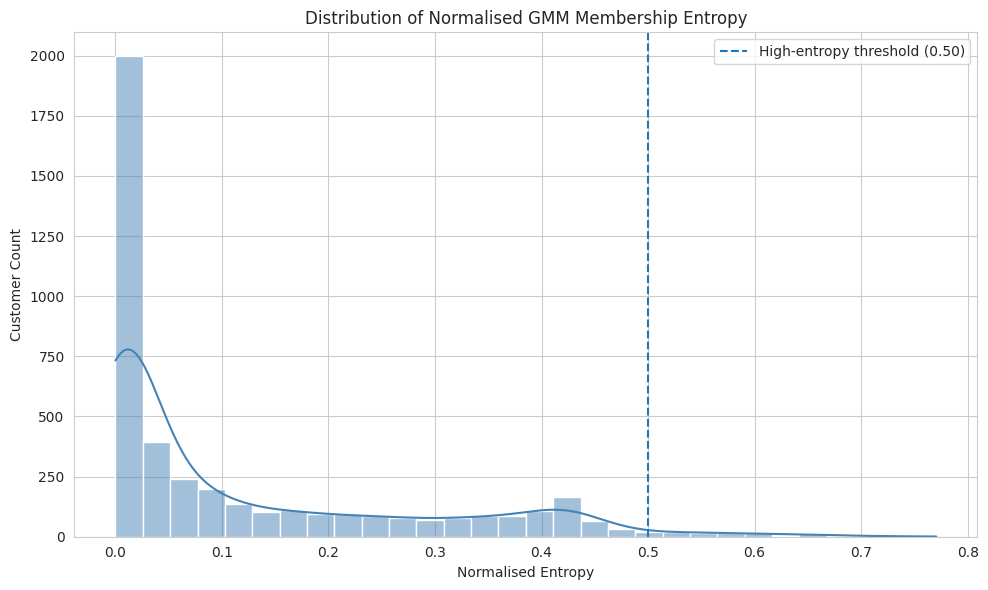

In [22]:
plt.figure(figsize=(10, 6))

sns.histplot(
    membership_data[
        "Maximum_Probability"
    ],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.axvline(
    LOW_MAX_PROBABILITY_THRESHOLD,
    linestyle="--",
    label=(
        "Low maximum-probability threshold "
        f"({LOW_MAX_PROBABILITY_THRESHOLD:.2f})"
    )
)

plt.title(
    "Distribution of Maximum GMM Membership Probability"
)
plt.xlabel("Maximum Posterior Probability")
plt.ylabel("Customer Count")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "maximum_membership_probability_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(10, 6))

sns.histplot(
    membership_data[
        "Probability_Margin"
    ],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.axvline(
    LOW_PROBABILITY_MARGIN_THRESHOLD,
    linestyle="--",
    label=(
        "Low probability-margin threshold "
        f"({LOW_PROBABILITY_MARGIN_THRESHOLD:.2f})"
    )
)

plt.title(
    "Distribution of GMM Probability Margin"
)
plt.xlabel(
    "Maximum Probability − Second Probability"
)
plt.ylabel("Customer Count")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "probability_margin_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(10, 6))

sns.histplot(
    membership_data[
        "Normalised_Entropy"
    ],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.axvline(
    HIGH_ENTROPY_THRESHOLD,
    linestyle="--",
    label=(
        "High-entropy threshold "
        f"({HIGH_ENTROPY_THRESHOLD:.2f})"
    )
)

plt.title(
    "Distribution of Normalised GMM Membership Entropy"
)
plt.xlabel("Normalised Entropy")
plt.ylabel("Customer Count")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "membership_entropy_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

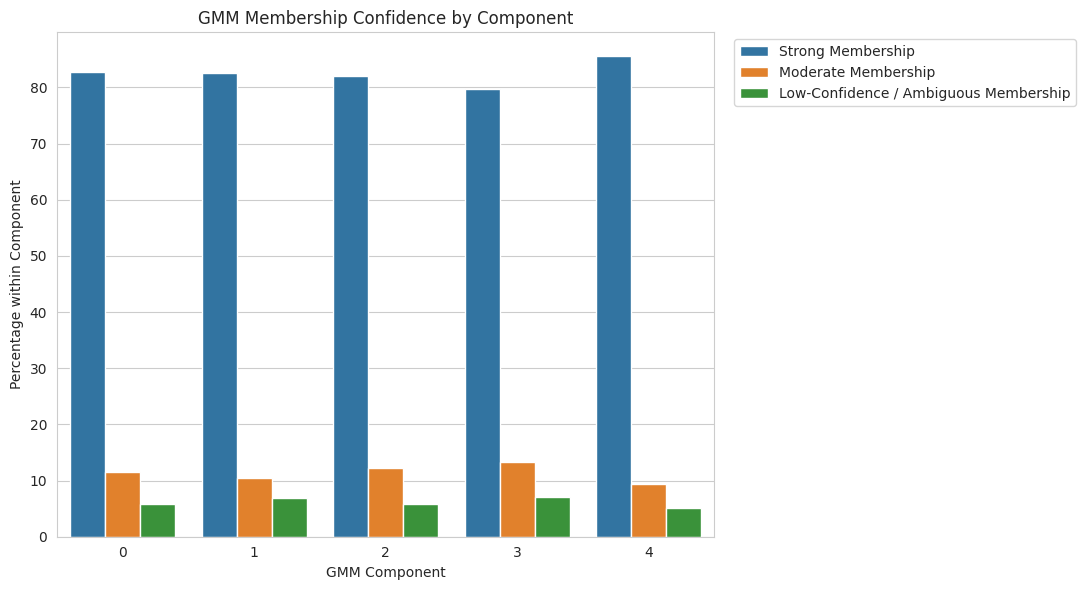

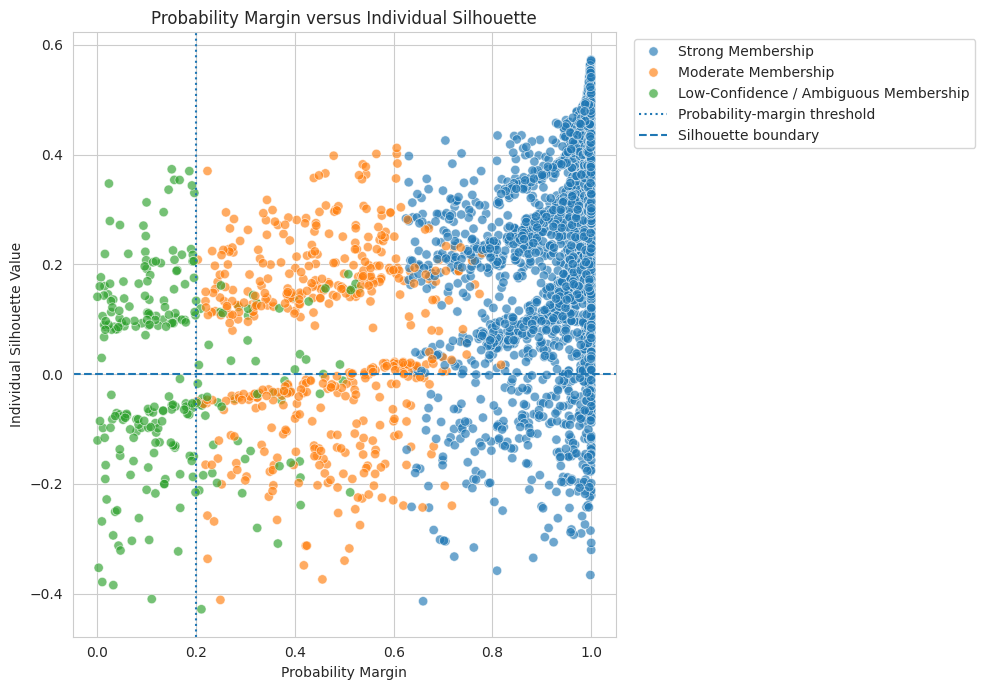

In [23]:
component_confidence_plot_data = (
    membership_data
    .groupby(
        [
            "GMM_Component",
            "Membership_Confidence_Category"
        ]
    )
    .size()
    .reset_index(
        name="Customer_Count"
    )
)

component_confidence_plot_data[
    "Customer_Percentage_Within_Component"
] = (
    component_confidence_plot_data[
        "Customer_Count"
    ]
    / component_confidence_plot_data
    .groupby(
        "GMM_Component"
    )[
        "Customer_Count"
    ]
    .transform("sum")
    * 100
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=component_confidence_plot_data,
    x="GMM_Component",
    y="Customer_Percentage_Within_Component",
    hue="Membership_Confidence_Category",
    hue_order=[
        "Strong Membership",
        "Moderate Membership",
        "Low-Confidence / Ambiguous Membership"
    ]
)

plt.title(
    "GMM Membership Confidence by Component"
)
plt.xlabel("GMM Component")
plt.ylabel("Percentage within Component")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "membership_confidence_by_component.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=membership_data,
    x="Probability_Margin",
    y="Silhouette_Value",
    hue="Membership_Confidence_Category",
    hue_order=[
        "Strong Membership",
        "Moderate Membership",
        "Low-Confidence / Ambiguous Membership"
    ],
    alpha=0.65,
    s=45
)

plt.axvline(
    LOW_PROBABILITY_MARGIN_THRESHOLD,
    linestyle=":",
    label="Probability-margin threshold"
)

plt.axhline(
    0,
    linestyle="--",
    label="Silhouette boundary"
)

plt.title(
    "Probability Margin versus Individual Silhouette"
)
plt.xlabel("Probability Margin")
plt.ylabel("Individual Silhouette Value")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "probability_margin_vs_silhouette.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

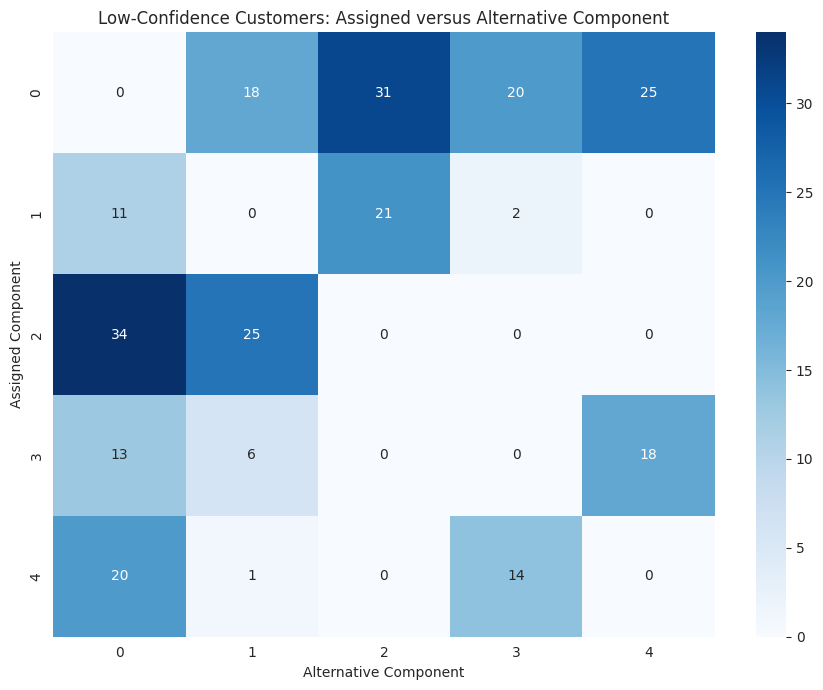

In [24]:
ambiguous_heatmap = pd.crosstab(
    ambiguous_customers[
        "GMM_Component"
    ],
    ambiguous_customers[
        "Alternative_GMM_Component"
    ]
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    ambiguous_heatmap,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Low-Confidence Customers: Assigned versus Alternative Component"
)
plt.xlabel("Alternative Component")
plt.ylabel("Assigned Component")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "ambiguous_component_overlap_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 14. Export final GMM membership datasets and tables


In [25]:
membership_data.to_csv(
    DATASETS_DIR
    / "final_gmm_customer_membership_analysis.csv",
    index=False
)

ambiguous_customers.to_csv(
    DATASETS_DIR
    / "final_gmm_low_confidence_customers.csv",
    index=False
)

condition_summary.to_csv(
    TABLES_DIR
    / "gmm_membership_condition_summary.csv",
    index=False
)

confidence_category_summary.to_csv(
    TABLES_DIR
    / "gmm_membership_confidence_summary.csv",
    index=False
)

probability_descriptive_summary.to_csv(
    TABLES_DIR
    / "gmm_probability_descriptive_summary.csv"
)

component_confidence_summary.to_csv(
    TABLES_DIR
    / "gmm_membership_confidence_by_component.csv",
    index=False
)

component_overlap_summary.to_csv(
    TABLES_DIR
    / "gmm_component_overlap_summary.csv",
    index=False
)

assigned_alternative_matrix.to_csv(
    TABLES_DIR
    / "gmm_assigned_vs_alternative_component_matrix.csv"
)

ambiguous_overlap_matrix.to_csv(
    TABLES_DIR
    / "gmm_ambiguous_component_overlap_matrix.csv"
)

probability_silhouette_cross_summary.to_csv(
    TABLES_DIR
    / "gmm_probability_silhouette_cross_summary.csv",
    index=False
)

confidence_silhouette_matrix.to_csv(
    TABLES_DIR
    / "gmm_confidence_silhouette_matrix.csv"
)

maximum_probability_sensitivity.to_csv(
    TABLES_DIR
    / "gmm_maximum_probability_threshold_sensitivity.csv",
    index=False
)

probability_margin_sensitivity.to_csv(
    TABLES_DIR
    / "gmm_probability_margin_threshold_sensitivity.csv",
    index=False
)

entropy_sensitivity.to_csv(
    TABLES_DIR
    / "gmm_entropy_threshold_sensitivity.csv",
    index=False
)

print(
    "Membership-analysis datasets and tables exported."
)

Membership-analysis datasets and tables exported.


## 15. Run Notebook 05 quality-control checks


In [26]:
assert len(membership_data) == EXPECTED_CUSTOMERS

assert membership_data[
    "CustomerID"
].is_unique

assert np.array_equal(
    membership_data[
        "GMM_Component"
    ].to_numpy(),
    frozen_labels
)

assert np.allclose(
    reproduced_probabilities.sum(axis=1),
    1.0
)

assert membership_data[
    "Maximum_Probability"
].between(
    0,
    1,
    inclusive="both"
).all()

assert membership_data[
    "Second_Probability"
].between(
    0,
    1,
    inclusive="both"
).all()

assert membership_data[
    "Probability_Margin"
].between(
    0,
    1,
    inclusive="both"
).all()

assert membership_data[
    "Normalised_Entropy"
].between(
    0,
    1,
    inclusive="both"
).all()

assert (
    membership_data[
        "Alternative_GMM_Component"
    ]
    != membership_data[
        "GMM_Component"
    ]
).all()

assert (
    confidence_category_summary[
        "Customer_Count"
    ].sum()
    == EXPECTED_CUSTOMERS
)

assert (
    len(ambiguous_customers)
    == int(
        combined_ambiguous_flag.sum()
    )
)

required_outputs = [
    DATASETS_DIR
    / "final_gmm_customer_membership_analysis.csv",
    DATASETS_DIR
    / "final_gmm_low_confidence_customers.csv",
    TABLES_DIR
    / "gmm_membership_condition_summary.csv",
    TABLES_DIR
    / "gmm_membership_confidence_summary.csv",
    TABLES_DIR
    / "gmm_membership_confidence_by_component.csv",
    TABLES_DIR
    / "gmm_component_overlap_summary.csv",
    TABLES_DIR
    / "gmm_probability_silhouette_cross_summary.csv",
    TABLES_DIR
    / "gmm_probability_margin_threshold_sensitivity.csv"
]

missing_outputs = [
    str(path)
    for path in required_outputs
    if not path.exists()
]

if missing_outputs:
    raise FileNotFoundError(
        "Missing required outputs:\n"
        + "\n".join(
            missing_outputs
        )
    )

quality_checks = pd.DataFrame({
    "Quality_Check": [
        "Customer count remains 4,338",
        "CustomerID values are unique",
        "Frozen component assignments reproduced",
        "Posterior probabilities sum to one",
        "Maximum probabilities valid",
        "Second probabilities valid",
        "Probability margins valid",
        "Normalised entropy valid",
        "Alternative component differs from assigned component",
        "Confidence category counts sum to 4,338",
        "Low-confidence dataset count consistent",
        "Required output files created"
    ],
    "Passed": [
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True
    ]
})

display(quality_checks)

quality_checks.to_csv(
    QUALITY_DIR
    / "gmm_membership_analysis_quality_checks.csv",
    index=False
)

print(
    "All GMM membership-analysis quality checks passed."
)

,Quality_Check,Passed
0,"Customer count remains 4,338",True
1,CustomerID values are unique,True
2,Frozen component assignments reproduced,True
3,Posterior probabilities sum to one,True
4,Maximum probabilities valid,True
5,Second probabilities valid,True
6,Probability margins valid,True
7,Normalised entropy valid,True
8,Alternative component differs from assigned co...,True
9,"Confidence category counts sum to 4,338",True


All GMM membership-analysis quality checks passed.


## 16. Create the final GMM membership summary


In [27]:
ambiguous_count = int(
    combined_ambiguous_flag.sum()
)

ambiguous_percentage = float(
    combined_ambiguous_flag.mean()
    * 100
)

negative_silhouette_count = int(
    (
        individual_silhouette < 0
    ).sum()
)

negative_silhouette_percentage = float(
    (
        individual_silhouette < 0
    ).mean()
    * 100
)

supervisor_summary = f'''
FINAL GMM C5 CUSTOMER MEMBERSHIP ANALYSIS

Frozen model
------------
Configuration: GMM_C5_spherical
Customers: {len(X):,}
Features: {len(FEATURE_COLUMNS)}
Components: {EXPECTED_COMPONENTS}
Overall Silhouette Score: {overall_silhouette:.4f}

Probability evidence
--------------------
Mean maximum probability:
{maximum_probability.mean():.4f}

Median maximum probability:
{np.median(maximum_probability):.4f}

Mean probability margin:
{probability_margin.mean():.4f}

Median probability margin:
{np.median(probability_margin):.4f}

Mean normalised entropy:
{normalised_entropy.mean():.4f}

Customer-level review conditions
--------------------------------
Maximum probability below {LOW_MAX_PROBABILITY_THRESHOLD:.2f}:
{int(low_max_probability_flag.sum()):,}
({low_max_probability_flag.mean() * 100:.2f}%)

Probability margin below {LOW_PROBABILITY_MARGIN_THRESHOLD:.2f}:
{int(low_probability_margin_flag.sum()):,}
({low_probability_margin_flag.mean() * 100:.2f}%)

Normalised entropy above {HIGH_ENTROPY_THRESHOLD:.2f}:
{int(high_entropy_flag.sum()):,}
({high_entropy_flag.mean() * 100:.2f}%)

Combined low-confidence / ambiguous group:
{ambiguous_count:,}
({ambiguous_percentage:.2f}%)

Negative-Silhouette customers:
{negative_silhouette_count:,}
({negative_silhouette_percentage:.2f}%)

Interpretation
--------------
The combined low-confidence group is a descriptive customer-review
group. It does not represent supervised misclassification.

Posterior probability, probability margin, entropy and Silhouette
measure related but different aspects of customer membership.

The next stage should compare these frozen GMM assignments and
confidence measures with the frozen K-Means K=5 model.
'''.strip()

with open(
    RESULTS_DIR
    / "supervisor_gmm_membership_summary.txt",
    "w"
) as file:
    file.write(
        supervisor_summary
    )

print(supervisor_summary)

FINAL GMM C5 CUSTOMER MEMBERSHIP ANALYSIS

Frozen model
------------
Configuration: GMM_C5_spherical
Customers: 4,338
Features: 7
Components: 5
Overall Silhouette Score: 0.2299

Probability evidence
--------------------
Mean maximum probability:
0.9221

Median maximum probability:
0.9908

Mean probability margin:
0.8503

Median probability margin:
0.9827

Mean normalised entropy:
0.1201

Customer-level review conditions
--------------------------------
Maximum probability below 0.60:
227
(5.23%)

Probability margin below 0.20:
194
(4.47%)

Normalised entropy above 0.50:
103
(2.37%)

Combined low-confidence / ambiguous group:
259
(5.97%)

Negative-Silhouette customers:
628
(14.48%)

Interpretation
--------------
The combined low-confidence group is a descriptive customer-review
group. It does not represent supervised misclassification.

Posterior probability, probability margin, entropy and Silhouette
measure related but different aspects of customer membership.

The next stage should c

## 17. Save the Notebook 05 methodology manifest


In [28]:
membership_manifest = {
    "model": {
        "configuration": "GMM_C5_spherical",
        "n_components": EXPECTED_COMPONENTS,
        "covariance_type": (
            EXPECTED_COVARIANCE_TYPE
        ),
        "retrained_in_this_notebook": False
    },
    "dataset": {
        "customers": int(
            len(X)
        ),
        "features": FEATURE_COLUMNS
    },
    "main_descriptive_thresholds": {
        "low_maximum_probability": (
            LOW_MAX_PROBABILITY_THRESHOLD
        ),
        "low_probability_margin": (
            LOW_PROBABILITY_MARGIN_THRESHOLD
        ),
        "high_normalised_entropy": (
            HIGH_ENTROPY_THRESHOLD
        ),
        "strong_membership_minimum_probability": (
            STRONG_MAX_PROBABILITY_THRESHOLD
        ),
        "strong_membership_minimum_margin": (
            STRONG_PROBABILITY_MARGIN_THRESHOLD
        ),
        "strong_membership_maximum_entropy": (
            STRONG_ENTROPY_THRESHOLD
        ),
        "note": (
            "Transparent dissertation-specific review "
            "conditions rather than universal GMM standards."
        )
    },
    "outputs": {
        "customer_membership_dataset": (
            "final_gmm_customer_membership_analysis.csv"
        ),
        "low_confidence_dataset": (
            "final_gmm_low_confidence_customers.csv"
        ),
        "component_overlap_summary": (
            "gmm_component_overlap_summary.csv"
        )
    },
    "next_step": (
        "Compare frozen K-Means K=5 and frozen "
        "GMM C5 spherical assignments."
    )
}

with open(
    RESULTS_DIR
    / "gmm_membership_analysis_manifest.json",
    "w"
) as file:
    json.dump(
        membership_manifest,
        file,
        indent=4
    )

print(
    "Membership-analysis manifest saved."
)

Membership-analysis manifest saved.


## 18. Package all Notebook 05 results into one ZIP

The final archive contains the complete customer-level membership dataset, the ambiguous-customer subset, summary tables, threshold-sensitivity analysis, figures, quality checks and methodology records.


In [29]:
zip_path = shutil.make_archive(
    base_name=str(
        BASE_DIR
        / "05_Final_GMM_C5_Spherical_and_Membership_All_Results"
    ),
    format="zip",
    root_dir=RESULTS_DIR
)

print("=" * 80)
print("NOTEBOOK 05 — FINAL GMM MEMBERSHIP ANALYSIS COMPLETED")
print("=" * 80)

print("\nResults folder:")
print(RESULTS_DIR)

print("\nZIP archive:")
print(zip_path)

print("\nKey outputs:")
print("1. Datasets/final_gmm_customer_membership_analysis.csv")
print("2. Datasets/final_gmm_low_confidence_customers.csv")
print("3. Tables/gmm_membership_condition_summary.csv")
print("4. Tables/gmm_membership_confidence_summary.csv")
print("5. Tables/gmm_membership_confidence_by_component.csv")
print("6. Tables/gmm_component_overlap_summary.csv")
print("7. Tables/gmm_probability_silhouette_cross_summary.csv")
print("8. Quality_Checks/gmm_membership_analysis_quality_checks.csv")
print("9. supervisor_gmm_membership_summary.txt")
print("10. gmm_membership_analysis_manifest.json")

try:
    from google.colab import files
    files.download(zip_path)
except Exception:
    print(
        "\nAutomatic ZIP download is available "
        "when running in Google Colab."
    )


NOTEBOOK 05 — FINAL GMM MEMBERSHIP ANALYSIS COMPLETED

Results folder:
/content/05_Final_GMM_C5_Spherical_and_Membership_Results

ZIP archive:
/content/05_Final_GMM_C5_Spherical_and_Membership_All_Results.zip

Key outputs:
1. Datasets/final_gmm_customer_membership_analysis.csv
2. Datasets/final_gmm_low_confidence_customers.csv
3. Tables/gmm_membership_condition_summary.csv
4. Tables/gmm_membership_confidence_summary.csv
5. Tables/gmm_membership_confidence_by_component.csv
6. Tables/gmm_component_overlap_summary.csv
7. Tables/gmm_probability_silhouette_cross_summary.csv
8. Quality_Checks/gmm_membership_analysis_quality_checks.csv
9. supervisor_gmm_membership_summary.txt
10. gmm_membership_analysis_manifest.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final reporting guidance and handoff to Notebook 06

Report GMM evidence in two separate layers:

### Model-level reliability — established in Notebook 04
- convergence;
- component feasibility;
- random-seed ARI;
- repeated 80% subsampling ARI;
- common internal validation.

### Customer-level membership evidence — established in Notebook 05
- maximum posterior probability;
- second-highest probability;
- probability margin;
- normalised entropy;
- alternative component;
- individual Silhouette value;
- descriptive ambiguous review group.


Notebook 06 will compare the frozen **K-Means K=5** and **GMM C5 Spherical** partitions, align the arbitrary component labels, quantify customer agreement and uncertainty overlap, and complete the final operational-model decision.
